In [1]:
import gurobipy as gp
from gurobipy import GRB
import itertools
from collections.abc import Mapping, Sequence

from instance import Instance, Arc, Node

instance = Instance()
world = instance.world
scenarios = instance.scenarios
demands = instance.demands
capacities = instance.capacities
paths_per_od = instance.paths_per_od
tau = instance.tau
phi = instance.phi

model = gp.Model("asymmetric")
model.setParam("OutputFlag", 0)

V = world.ordered_nodes
A = world.ordered_arcs
I = world.I
N = world.individuals

n = world.total_population
t = world.network.travel_time
c = world.network.capacity
alpha = world.network.bpr_alpha
beta = world.network.bpr_beta

Set parameter Username
Set parameter LicenseID to value 2844113
Academic license - for non-commercial use only - expires 2027-07-13


In [2]:
path_as_set = {
    path: set(path)
    for paths in paths_per_od.values()
    for path in paths
}

T = {
    od: i
    for i, od in enumerate(demands.keys())
}

active_arcs = set(
    itertools.chain.from_iterable(
        itertools.chain.from_iterable(paths_per_od.values())
    )
)

profiles_per_od = {
    od: list(itertools.combinations_with_replacement(paths_per_od[od], n_k))
    for od, n_k in demands.items()
}

joint_action_profiles = list(itertools.product(*profiles_per_od.values()))

action_profile_flows: Sequence[Mapping[Arc, int]] = []
for joint_profile in joint_action_profiles:
    flow = {a: 0 for a in active_arcs}
    for od_profile in joint_profile:
        for path in od_profile:
            for a in path:
                flow[a] += 1
    action_profile_flows.append(flow)

for od, paths in paths_per_od.items():
    print(od)
    for i, path in enumerate(paths):
        print("\t", f"{i}:", path)
    print("\n")

# NOTE: vvv is underestimate b/c of left-facing edges
print(f"{len(active_arcs)=} ({len(active_arcs) / len(A) * 100:.2f}% of arcs)")
print(f"{len(profiles_per_od)=}")
print(f"{len(joint_action_profiles)=}")

((0, 0), (0, 3))
	 0: (((0, 0), (0, 1)), ((0, 1), (0, 2)), ((0, 2), (0, 3)))
	 1: (((0, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (0, 1)), ((0, 1), (0, 2)), ((0, 2), (0, 3)))
	 2: (((0, 0), (0, 1)), ((0, 1), (0, 2)), ((0, 2), (1, 2)), ((1, 2), (1, 3)), ((1, 3), (0, 3)))
	 3: (((0, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (2, 1)), ((2, 1), (2, 2)), ((2, 2), (2, 3)), ((2, 3), (1, 3)), ((1, 3), (0, 3)))


((2, 0), (2, 3))
	 0: (((2, 0), (2, 1)), ((2, 1), (2, 2)), ((2, 2), (2, 3)))
	 1: (((2, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (2, 1)), ((2, 1), (2, 2)), ((2, 2), (2, 3)))
	 2: (((2, 0), (2, 1)), ((2, 1), (1, 1)), ((1, 1), (1, 2)), ((1, 2), (2, 2)), ((2, 2), (2, 3)))
	 3: (((2, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (1, 2)), ((1, 2), (1, 3)), ((1, 3), (2, 3)))


len(active_arcs)=19 (55.88% of arcs)
len(profiles_per_od)=2
len(joint_action_profiles)=81796


In [3]:
# decision: sigma[omega, a] := \prob[a \mid \theta]
sigma = {}
for scenario_name in scenarios:
    for action_profile_idx in range(len(joint_action_profiles)):
        sigma[scenario_name, action_profile_idx] = model.addVar(
            vtype=GRB.CONTINUOUS, lb=0, ub=1,
            name=f"sigma_{scenario_name}_{action_profile_idx}"
        )

# constraint: \sum_{rho \in \mathcal{A}} sigma[\omega, rho] = 1
for scenario_name in scenarios:
    model.addConstr(
        gp.quicksum(
            sigma[scenario_name, action_profile_idx]
            for action_profile_idx in range(len(joint_action_profiles))
        ) == 1,
        name=f"sigma_{scenario_name}"
    )

In [4]:
def debug_model():
    model.optimize()
    assert model.Status == GRB.OPTIMAL, f"Optimization failed: {model.Status}"

    out = []
    out.append(f"{model.ObjVal=:.2f}")
    out.append(f"{model.Runtime=:.3f}s")

    for scenario_name in scenarios:
        out.append(f"\nState: {scenario_name}")

        for action_profile_idx, joint_profile in enumerate(joint_action_profiles):
            prob = sigma[scenario_name, action_profile_idx].X
            if prob > 1e-3:
                out.append(f"\tJoint Profile {action_profile_idx}: ({prob=:.3f})")
                for od, od_profile in zip(profiles_per_od.keys(), joint_profile):
                    path_flows = tuple(od_profile.count(path) for path in paths_per_od[od])
                    out.append(f"\t\t{od}: {path_flows}")

    return out, model.ObjVal

In [5]:
# objective: expected potential
expected_potential = gp.LinExpr()

# objective: expected social cost
expected_social_cost = gp.LinExpr()

for scenario_name, mu in scenarios.items():
    for action_profile_idx, flows in enumerate(action_profile_flows):
        sigma_var = sigma[scenario_name, action_profile_idx]

        potential = sum(
            phi[scenario_name, a, flow]
            for a, flow in flows.items()
        )
        expected_potential.addTerms(mu * potential, sigma_var)

        cost = sum(
            flow * tau[scenario_name, a, flow]
            for a, flow in flows.items()
        )
        expected_social_cost.addTerms(mu * cost,  sigma_var)

In [6]:
model.setObjective(expected_potential, GRB.MINIMIZE)
selfish_out, _ = debug_model()
selfish_cost = expected_social_cost.getValue()

In [7]:
model.setObjective(expected_social_cost, GRB.MINIMIZE)
dictator_out, dictator_cost = debug_model()

In [8]:
# constraint: obedience (IC?)
for od, paths in paths_per_od.items():
    od_idx = T[od]
    expected_deviate_benefit = {
        (p0_idx, p1_idx): gp.LinExpr()
        for p0_idx in range(len(paths))
        for p1_idx in range(len(paths))
        if p0_idx != p1_idx
    }

    for scenario_name, mu in scenarios.items():
        for action_profile_idx, joint_profile in enumerate(joint_action_profiles):
            od_profile = joint_profile[od_idx]
            flow = action_profile_flows[action_profile_idx]
            sigma_var = sigma[scenario_name, action_profile_idx]

            for p0_idx, p0 in enumerate(paths):
                # NOTE: below is slow yet no point in memoizing b/c only done once anyways
                # better solution is to make e/a action profile a tuple of frequencies, rather than a tuple of paths
                # but overall pretty negligible, probably
                count = od_profile.count(p0) # num of agents of type OD routed to path p0 under the joint profile
                if count == 0:
                    continue

                cost_follow = sum(tau[scenario_name, a, flow[a]] for a in p0)
                p0_set = path_as_set[p0]

                for p1_idx, p1 in enumerate(paths):
                    if p0_idx == p1_idx:
                        continue

                    cost_deviate = sum(
                        tau[scenario_name, a, flow[a] if a in p0_set else flow[a] + 1]
                        for a in p1
                    )

                    # faster than +=
                    expected_deviate_benefit[p0_idx, p1_idx].addTerms(
                        mu * count * (cost_follow - cost_deviate),
                        sigma_var
                    )

    for (p0_idx, p1_idx), expr in expected_deviate_benefit.items():
        model.addConstr(
            expr <= 0,
            name=f"obed_{od}_{p0_idx}_to_{p1_idx}"
        )

In [9]:
shaki_out, shaki_cost = debug_model()

In [10]:
print("Expected Social Costs:")
print(f"\tDICTATOR:\t{dictator_cost:.2f}")
print(f"\tSELFISH:\t{selfish_cost:.2f} ({selfish_cost / dictator_cost:.4f})")
print(f"\tSHAKI:\t\t{shaki_cost:.2f} ({shaki_cost / dictator_cost:.4f})")

Expected Social Costs:
	DICTATOR:	191.66
	SELFISH:	247.29 (1.2903)
	SHAKI:		206.46 (1.0772)


In [11]:
for od, paths in paths_per_od.items():
    print(od)
    for i, path in enumerate(paths):
        print("\t", f"{i}:", path)
    print("\n")

print("="*25)
print("DICTATOR:\n\n")
print("\n".join(dictator_out))
print("\n\n" + "="*25)
print("SELFISH:\n\n")
print("\n".join(selfish_out))
print("\n\n" + "="*25)
print("SHAKI:\n\n")
print("\n".join(shaki_out))

((0, 0), (0, 3))
	 0: (((0, 0), (0, 1)), ((0, 1), (0, 2)), ((0, 2), (0, 3)))
	 1: (((0, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (0, 1)), ((0, 1), (0, 2)), ((0, 2), (0, 3)))
	 2: (((0, 0), (0, 1)), ((0, 1), (0, 2)), ((0, 2), (1, 2)), ((1, 2), (1, 3)), ((1, 3), (0, 3)))
	 3: (((0, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (2, 1)), ((2, 1), (2, 2)), ((2, 2), (2, 3)), ((2, 3), (1, 3)), ((1, 3), (0, 3)))


((2, 0), (2, 3))
	 0: (((2, 0), (2, 1)), ((2, 1), (2, 2)), ((2, 2), (2, 3)))
	 1: (((2, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (2, 1)), ((2, 1), (2, 2)), ((2, 2), (2, 3)))
	 2: (((2, 0), (2, 1)), ((2, 1), (1, 1)), ((1, 1), (1, 2)), ((1, 2), (2, 2)), ((2, 2), (2, 3)))
	 3: (((2, 0), (1, 0)), ((1, 0), (1, 1)), ((1, 1), (1, 2)), ((1, 2), (1, 3)), ((1, 3), (2, 3)))


DICTATOR:


model.ObjVal=191.66
model.Runtime=0.017s

State: nominal
	Joint Profile 5453: (prob=1.000)
		((0, 0), (0, 3)): (7, 0, 0, 3)
		((2, 0), (2, 3)): (7, 0, 0, 3)

State: accident
	Joint Profile 5453: (prob=1.000)
		((0, 0),

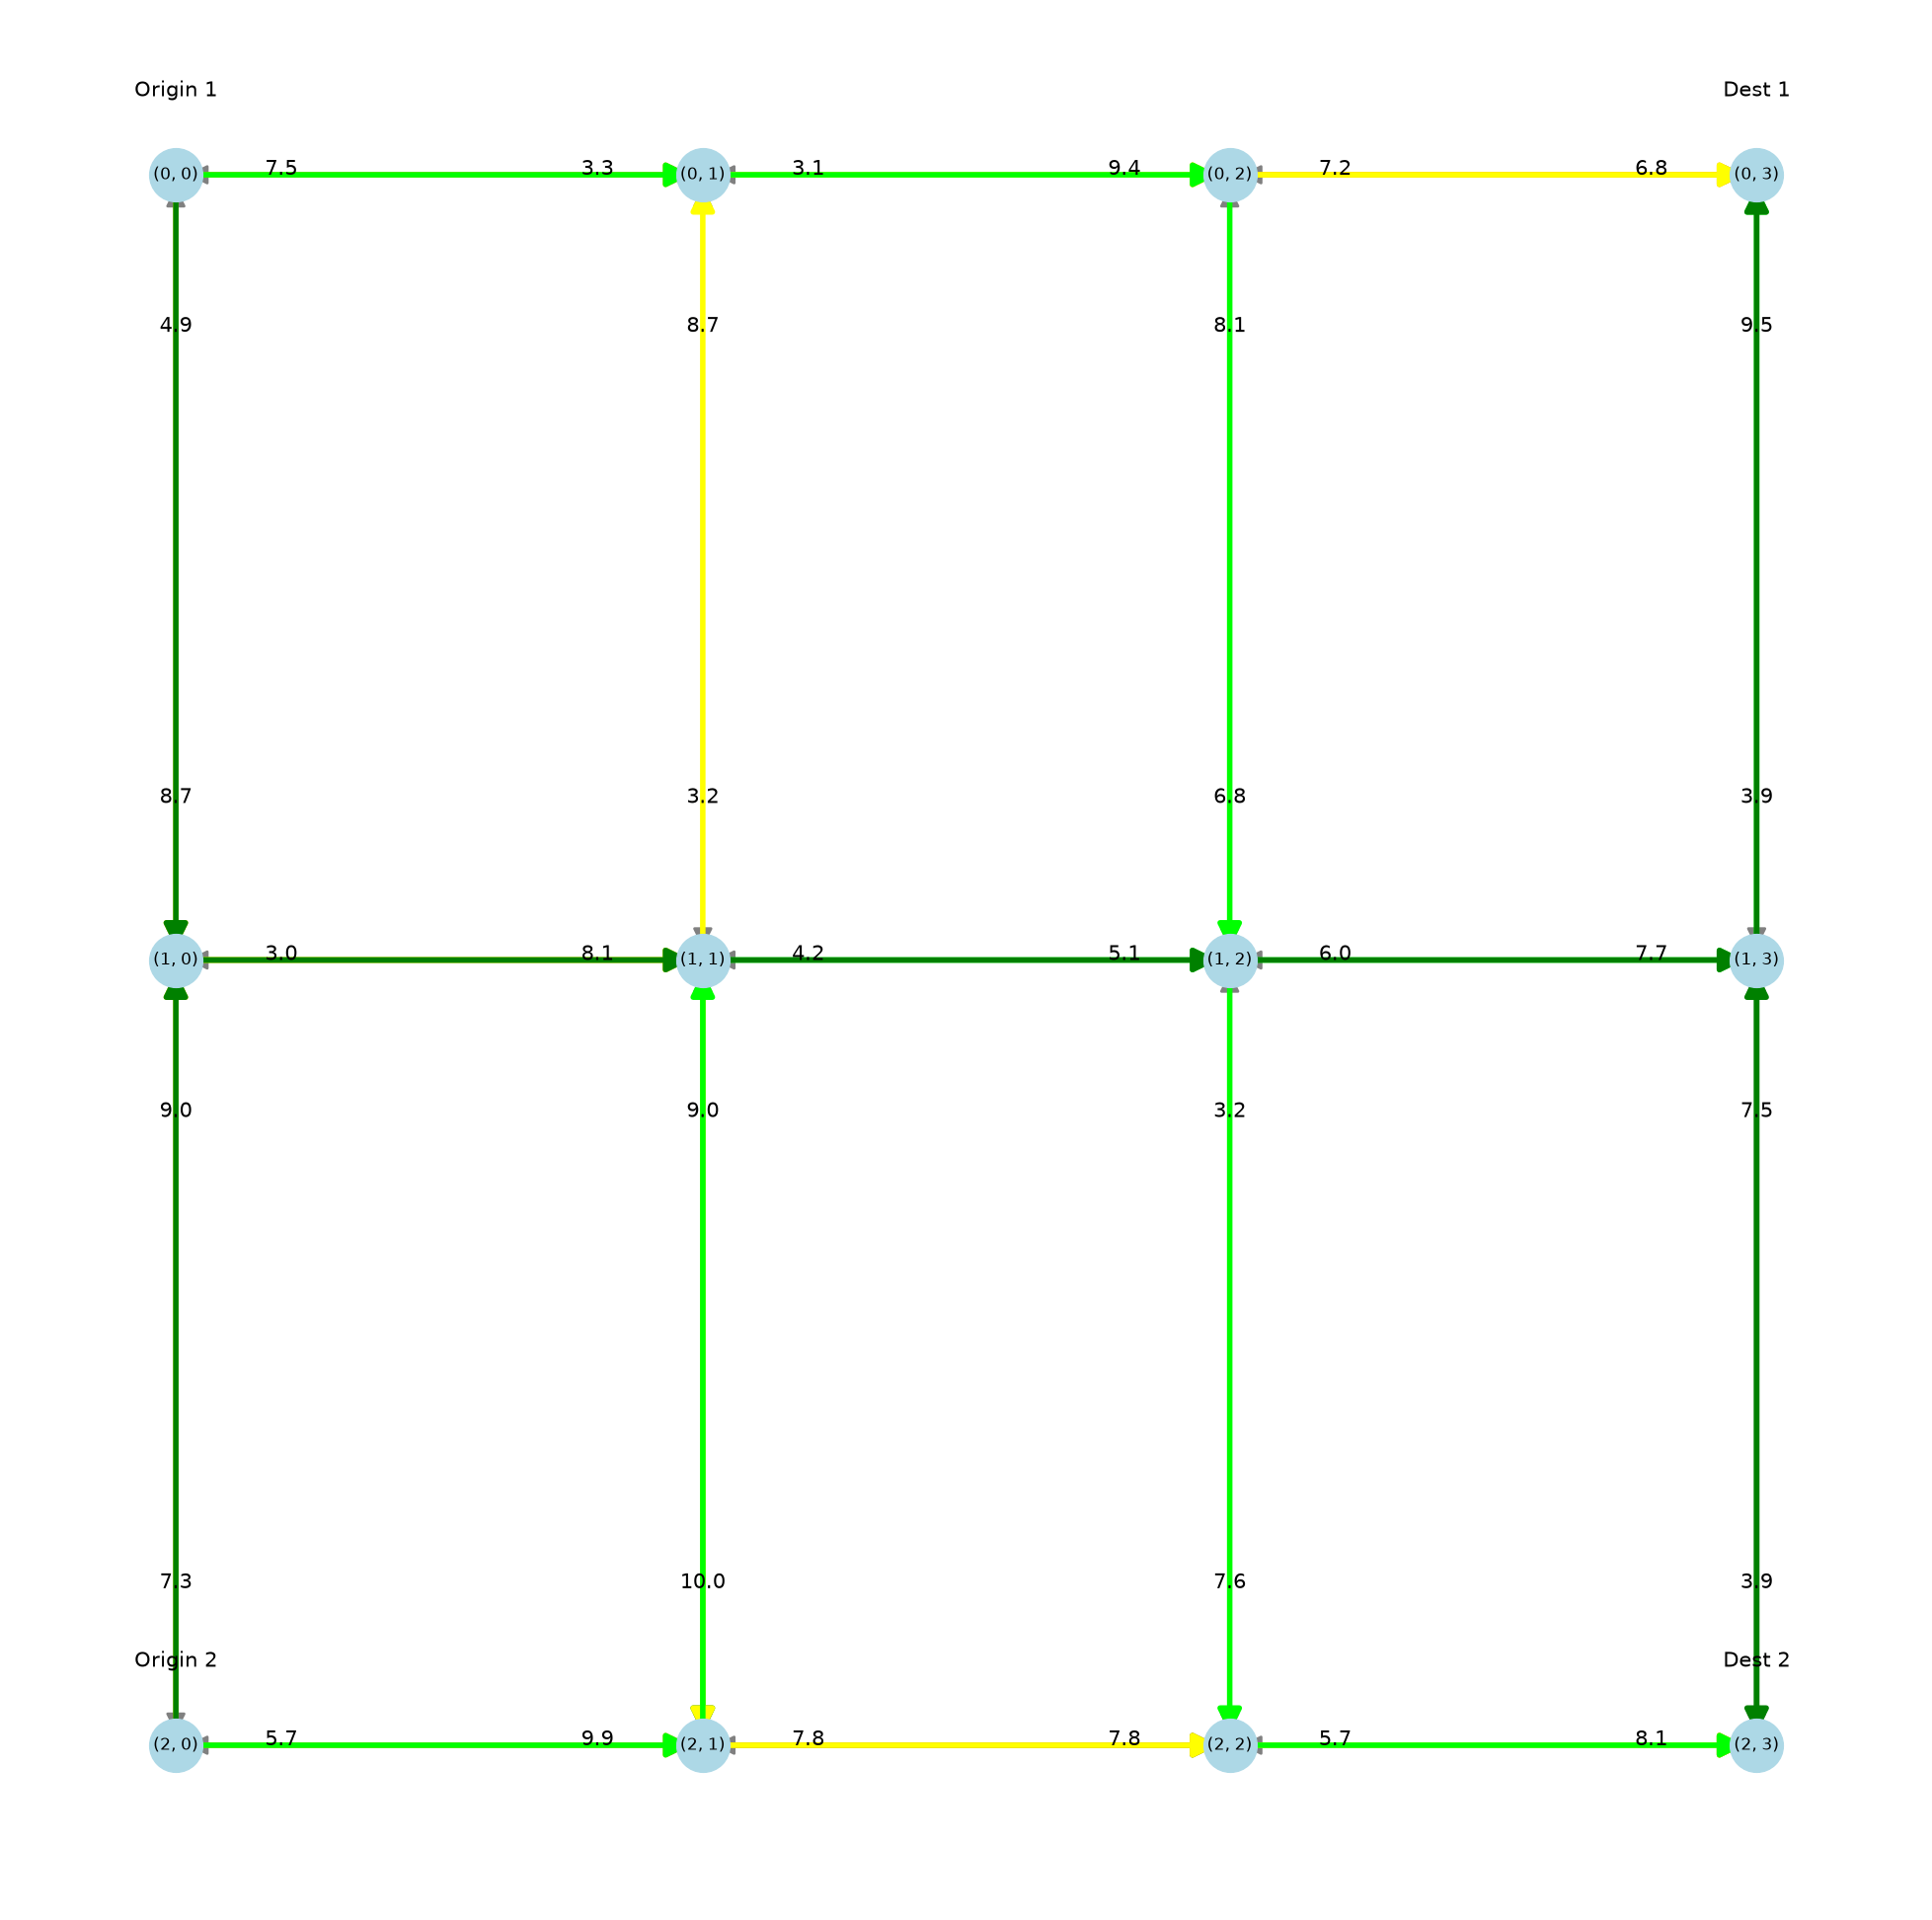

In [12]:
import networkx as nx
import matplotlib.pyplot as plt

G = world.network.graph
pos = {(r, c): (c, -r) for (r, c) in G.nodes}

plt.figure(figsize=(25, 25))

# draw nodes & edges
nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=1500)
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, G.edges(), edge_color="gray", arrows=True, width=2, arrowsize=30)

# draw arteries
nx.draw_networkx_edges(G, pos, edgelist=instance.arteries, edge_color="crimson", arrows=True, width=4, arrowsize=35)

# label origins & destinations
for i, (origin, dest) in enumerate(instance.demands, 1):
    (x0, y0), (x1, y1) = pos[origin], pos[dest]
    plt.text(x0, y0 + .1, f"Origin {i}", fontsize=15, ha="center")
    plt.text(x1, y1 + .1, f"Dest {i}", fontsize=15, ha="center")

# label origins & destinations
for arc in G.edges():
    (x0, y0), (x1, y1) = pos[arc[0]], pos[arc[1]]
    x, y = (x0 + x1) / 2, (y0 + y1) / 2
    x_offset = (x0 - x1) * .3
    y_offset = (y0 - y1) * .3
    c0, c1 = capacities["nominal"][arc], capacities["accident"][arc]
    capacity = f"{c0:.1f}" if c0 == c1 else f"{c0:.1f}/{c1:.1f}"
    plt.text(x + x_offset, y + y_offset, capacity, fontsize=15, ha="center")

# draw chosen k-shortest paths
colors = ["orange", "yellow", "lime", "green", "teal", "blue", "navy", "purple", "magenta"]
for od, paths in paths_per_od.items():
    for i, path in enumerate(paths):
        nx.draw_networkx_edges(G, pos, edgelist=path, edge_color=colors[i], arrows=True, width=4, arrowsize=35)

plt.axis(False)
plt.show()
